# 🌾 Crop Recommendation System - Exploratory Data Analysis

### Dataset Description
The dataset contains **1650 samples** with the following features:

| Feature         | Description                   | Unit       |
|-----------------|-------------------------------|------------|
| **N**           | Nitrogen content in soil      |   kg/ha    |
| **P**           | Phosphorus content in soil    |   kg/ha    |
| **K**           | Potassium content in soil     |   kg/ha    |
| **temperature** | Average temperature           |      °C    |
| **humidity**    | Relative humidity             |       %    |
| **ph**          | Soil pH value                 |    0-14    |
| **rainfall**    | Annual rainfall               |      mm    |
| **label**       | Crop type (Target)            | Categorical|

### Business Impact
- Help farmers make data-driven decisions
- Optimize crop yield and reduce losses

In [95]:
#import libraries
# !pip3 install numpy pandas matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
#load dataset
data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"

df = pd.read_csv(data_url)

print("Total sample size: ", df.shape[0])
print("Total features: ", df.shape[1])
print(df.head())

Total sample size:  1650
Total features:  8
       N      P      K  temperature   humidity        ph    rainfall      crop
0   17.0  136.0  196.0    23.871923  90.499390  5.882156  103.054809     apple
1   49.0   69.0   82.0    18.315615  15.361435  7.263119   81.787105  chickpea
2   74.0   49.0   38.0    23.314104  71.450905  7.488014  164.497037      jute
3  104.0   35.0   28.0    27.510061  50.666872  6.983732  143.995555    coffee
4   23.0   72.0   84.0    19.020613  17.131591  6.920251   79.926981  chickpea


In [97]:
#data quality check

# for col in df.columns:
#     not_null = df[col].notna().sum()
#     is_null = df[col].isna().sum()
#     duplicates = df[col].duplicated().sum()
#     unique = df[col].nunique()
#     print(f"Column: {col}")
#     print("Not null: ", not_null, "Is null: ", is_null,
#     "#Duplicates: ", duplicates, "#Unique: ", unique)

# not_null = df.notna().sum()
# is_null = df.isna().sum()
# print("Not null: ")
# print(not_null)
# print("Is null: ")
# print(is_null)


In [98]:
# statistical measures
stats = df.describe().T
stats['range'] = stats['max'] - stats['min']
stats['iqr'] = stats['75%'] - stats['25%']

print(stats.round(2))

              count    mean    std    min    25%    50%     75%     max  \
N            1650.0   50.37  36.74   0.00  21.00  37.00   84.74  136.00   
P            1650.0   53.42  33.32   5.00  27.00  52.00   68.00  145.00   
K            1650.0   48.11  50.54   5.00  20.55  31.58   49.00  205.00   
temperature  1650.0   25.65   5.01   9.47  22.81  25.66   28.53   42.94   
humidity     1650.0   71.56  22.20  14.27  60.12  80.55   90.00   99.98   
ph           1650.0    6.49   0.77   3.53   5.99   6.43    6.92    9.94   
rainfall     1650.0  103.97  55.51  20.36  65.03  95.25  127.89  298.56   

              range    iqr  
N            136.00  63.74  
P            140.00  41.00  
K            200.00  28.45  
temperature   33.47   5.72  
humidity      85.71  29.88  
ph             6.41   0.94  
rainfall     278.20  62.86  


In [99]:
numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

stats = pd.DataFrame({
    col: {
        "mean":df[col].mean(),
        "median":df[col].median(),
        "mode":df[col].mode().iloc[0],
        "std":df[col].std(),
        "var":df[col].var(),
        "skew":df[col].skew(),
        "kurtosis":df[col].kurtosis(),
    } for col in numerical_cols
}).T

print(stats.round(2))

               mean  median   mode    std      var  skew  kurtosis
N             50.37   37.00  27.00  36.74  1350.12  0.51     -1.08
P             53.42   52.00  60.00  33.32  1110.26  1.00      0.84
K             48.11   31.58  17.00  50.54  2553.99  2.38      4.45
temperature   25.65   25.66   9.47   5.01    25.05  0.19      1.19
humidity      71.56   80.55  14.27  22.20   492.76 -1.10      0.33
ph             6.49    6.43   3.53   0.77     0.59  0.40      1.97
rainfall     103.97   95.25  20.36  55.51  3081.40  0.95      0.50


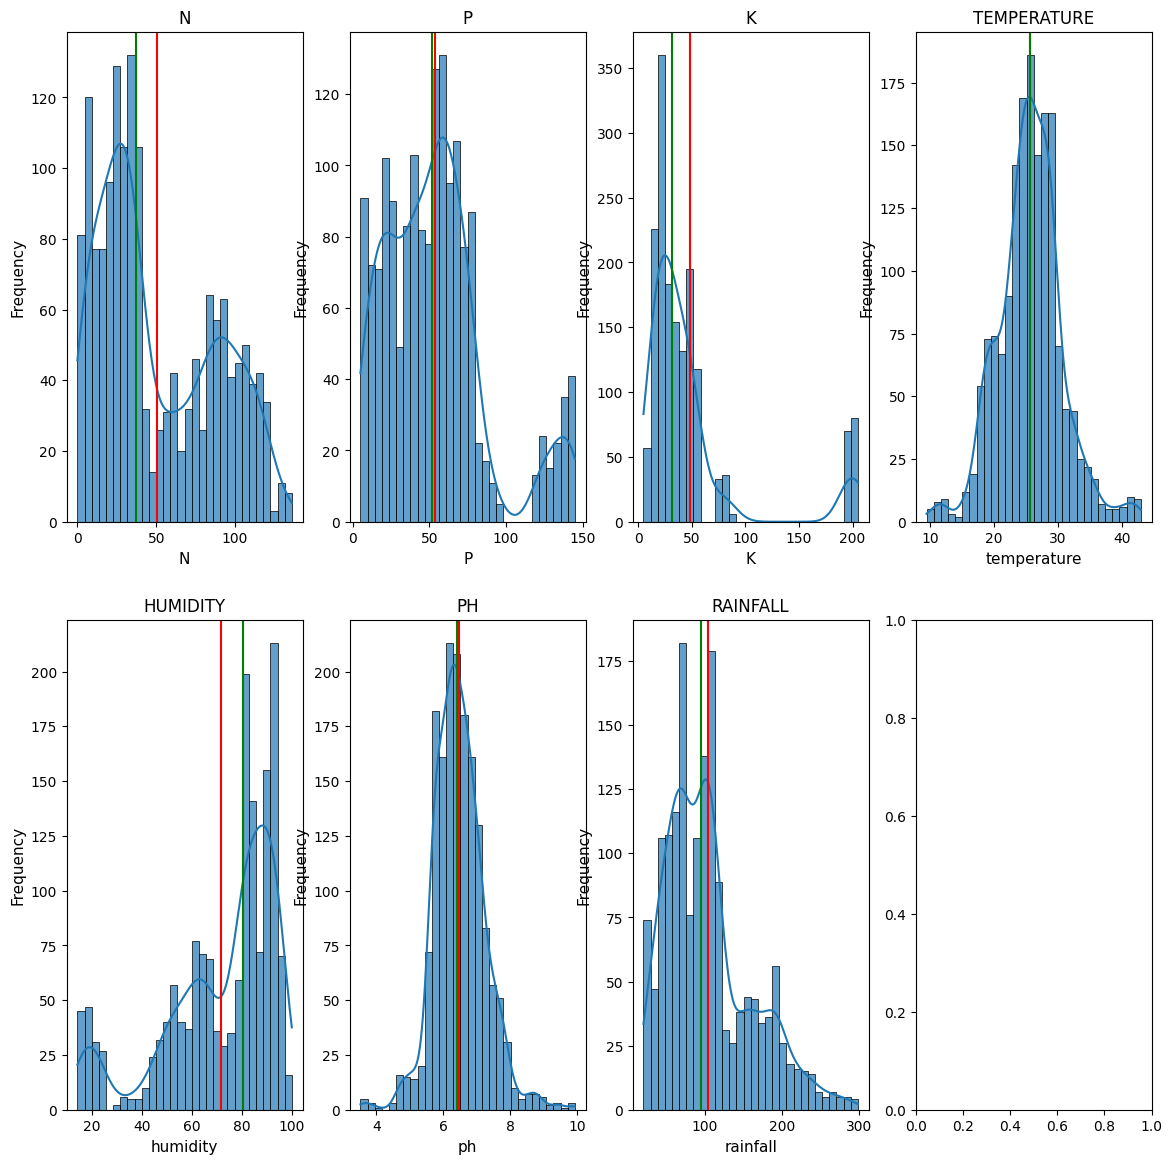

In [247]:
# feature distributions
fig, axes = plt.subplots(2, 4, figsize=(14, 14))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    
    # Histogram with KDE
    sns.histplot(data=df, x=col, kde=True, ax=ax,
                 edgecolor='black', alpha=0.7, bins=30)
    
    mean = df[col].mean()
    median = df[col].median()
    
    ax.axvline(mean, color='red', label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', label=f'Median: {median:.2f}')
    
    ax.set_title(f'{col.upper()}', fontsize=12)
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
               

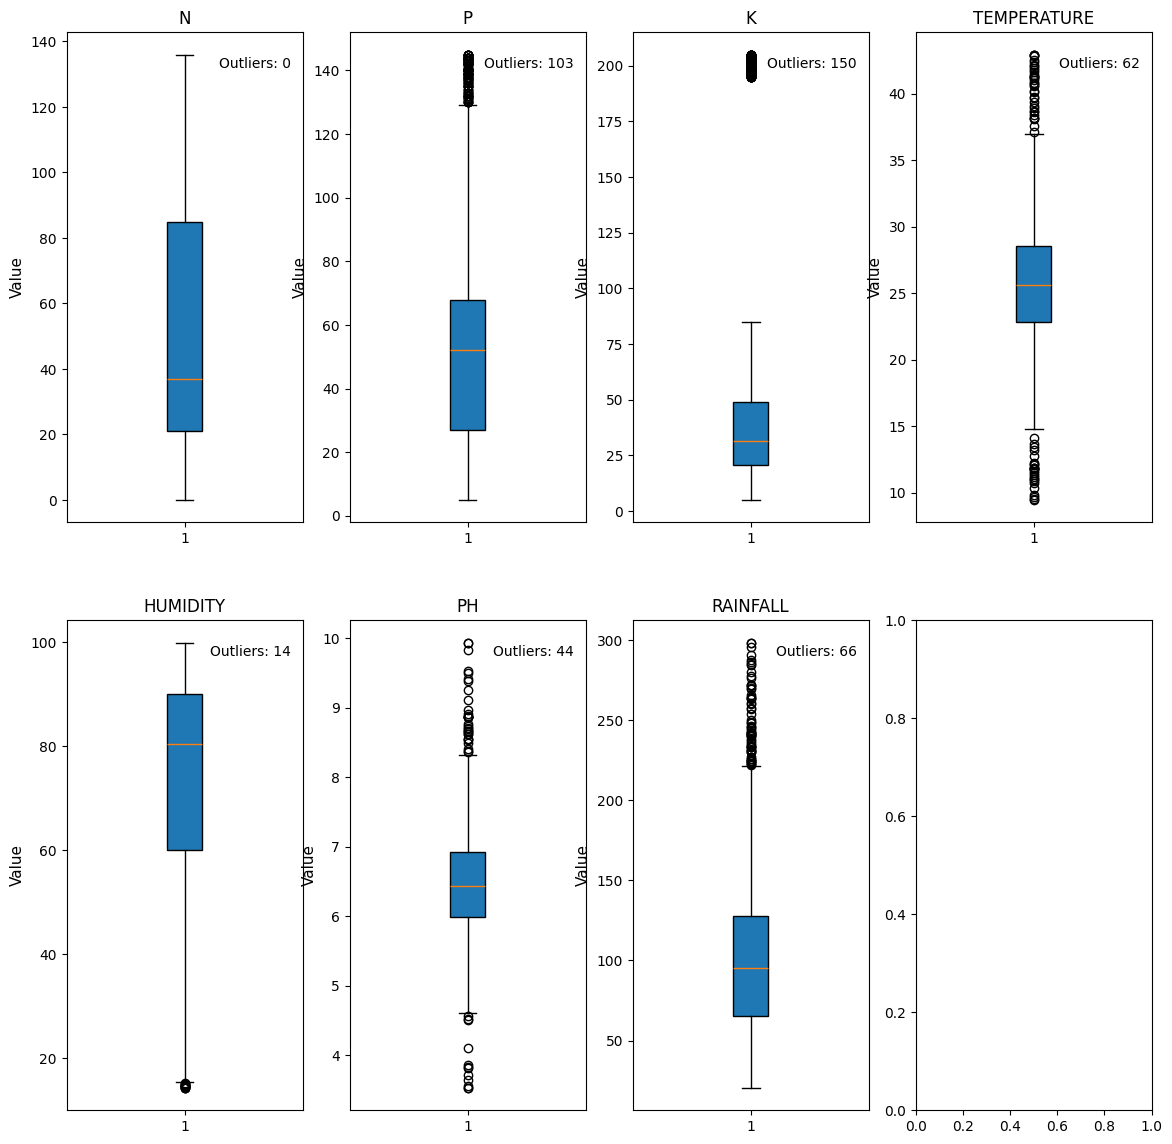

In [246]:
# box plots - outlier detection
fig, axes = plt.subplots(2, 4, figsize=(14, 14))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    ax = axes[idx]
    
    # Box plot
    bp = ax.boxplot(df[col], patch_artist=True)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    ax.set_title(f'{col.upper()}', fontsize=12)
    ax.set_ylabel('Value', fontsize=11)
    
    # Add outlier count
    outlier_text = f'Outliers: {len(outliers)}'
    ax.text(0.95, 0.95, outlier_text,transform=ax.transAxes, ha='right', va='top', fontsize=10)

In [102]:
outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col]<lower_bound)|(df[col]>upper_bound)][col]

    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers)/len(df)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.round(2))


       Feature     Q1      Q3    IQR  Lower Bound  Upper Bound  Outlier Count  \
0            N  21.00   84.74  63.74       -74.61       180.35              0   
1            P  27.00   68.00  41.00       -34.50       129.50            103   
2            K  20.55   49.00  28.45       -22.12        91.67            150   
3  temperature  22.81   28.53   5.72        14.22        37.11             62   
4     humidity  60.12   90.00  29.88        15.29       134.83             14   
5           ph   5.99    6.92   0.94         4.58         8.33             44   
6     rainfall  65.03  127.89  62.86       -29.27       222.18             66   

   Outlier %  
0       0.00  
1       6.24  
2       9.09  
3       3.76  
4       0.85  
5       2.67  
6       4.00  


In [119]:
crop_counts = df['crop'].value_counts()
print('Number of unique crops: ', len(crop_counts))
print('Crops: ', crop_counts.index)
print('Samples per crop: ', crop_counts.values)

# print(df)

Number of unique crops:  22
Crops:  Index(['apple', 'chickpea', 'jute', 'coffee', 'watermelon', 'coconut',
       'grapes', 'mango', 'mothbeans', 'pomegranate', 'mungbean', 'banana',
       'blackgram', 'orange', 'rice', 'lentil', 'maize', 'pigeonpeas',
       'kidneybeans', 'papaya', 'muskmelon', 'cotton'],
      dtype='object', name='crop')
Samples per crop:  [75 75 75 75 75 75 75 75 75 75 75 75 75 75 75 75 75 75 75 75 75 75]


Text(0.5, 1.0, 'Crop Distribution')

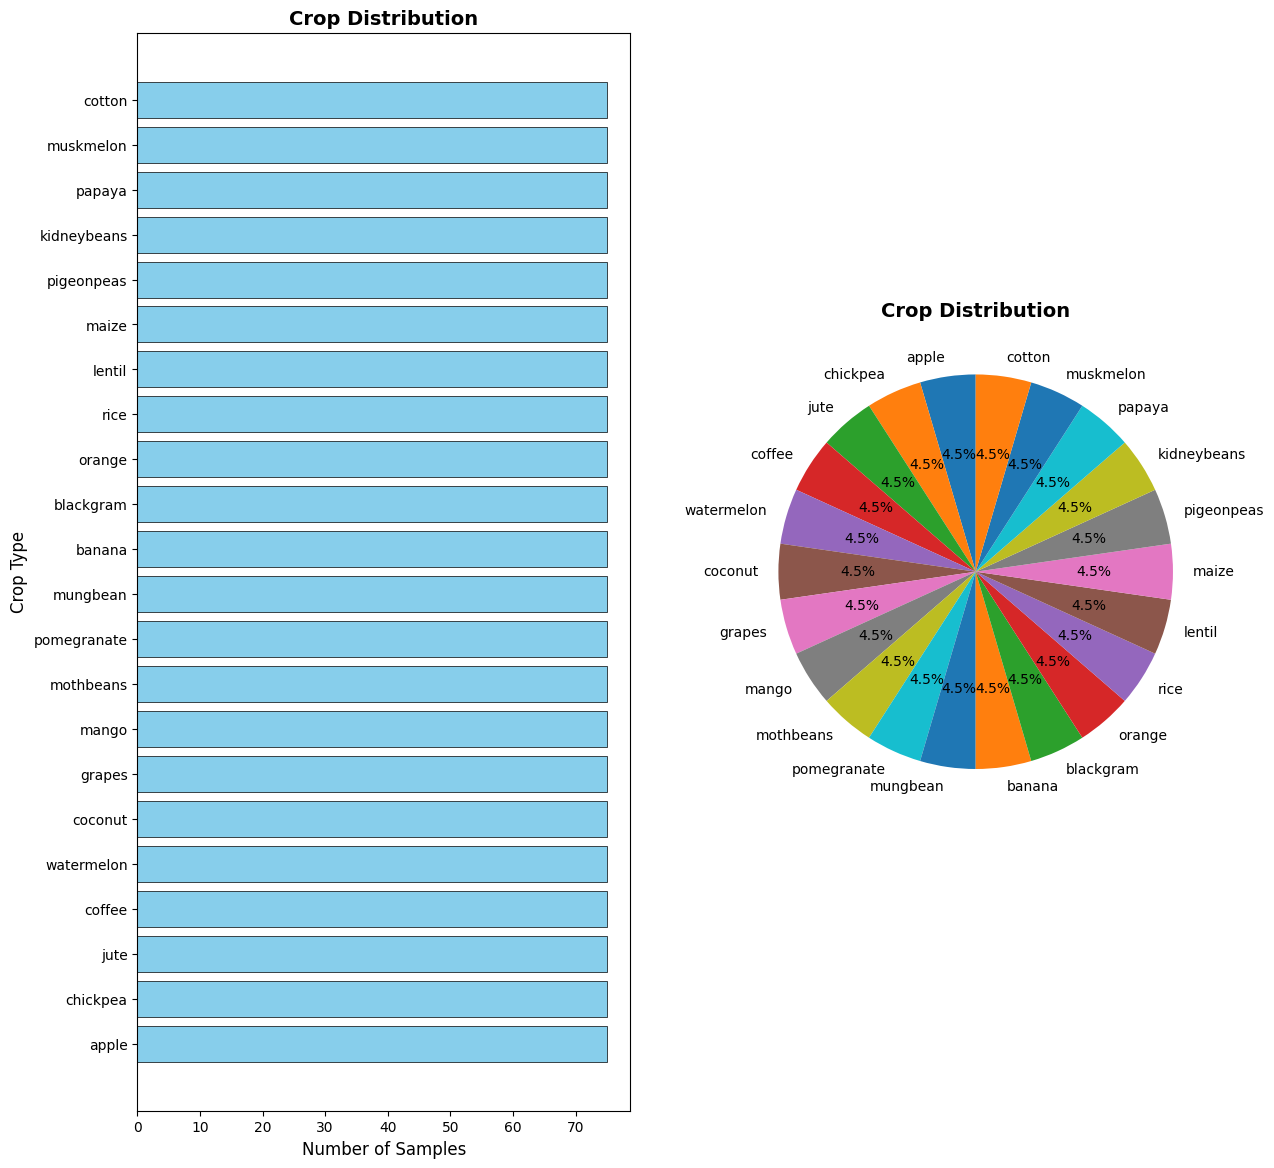

In [245]:
#bar graph
fig, axes = plt.subplots(1, 2, figsize=(14, 14))

axes[0].barh(crop_counts.index, crop_counts.values, color='skyblue',
                     linewidth=0.5, edgecolor='black')

axes[0].set_title('Crop Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Samples', fontsize=12)
axes[0].set_ylabel('Crop Type', fontsize=12)

#pie chart
pie = axes[1].pie(
    crop_counts.values, 
    labels=crop_counts.index,
    autopct='%1.1f%%',
    startangle=90,
)

axes[1].set_title('Crop Distribution', fontsize=14, fontweight='bold')

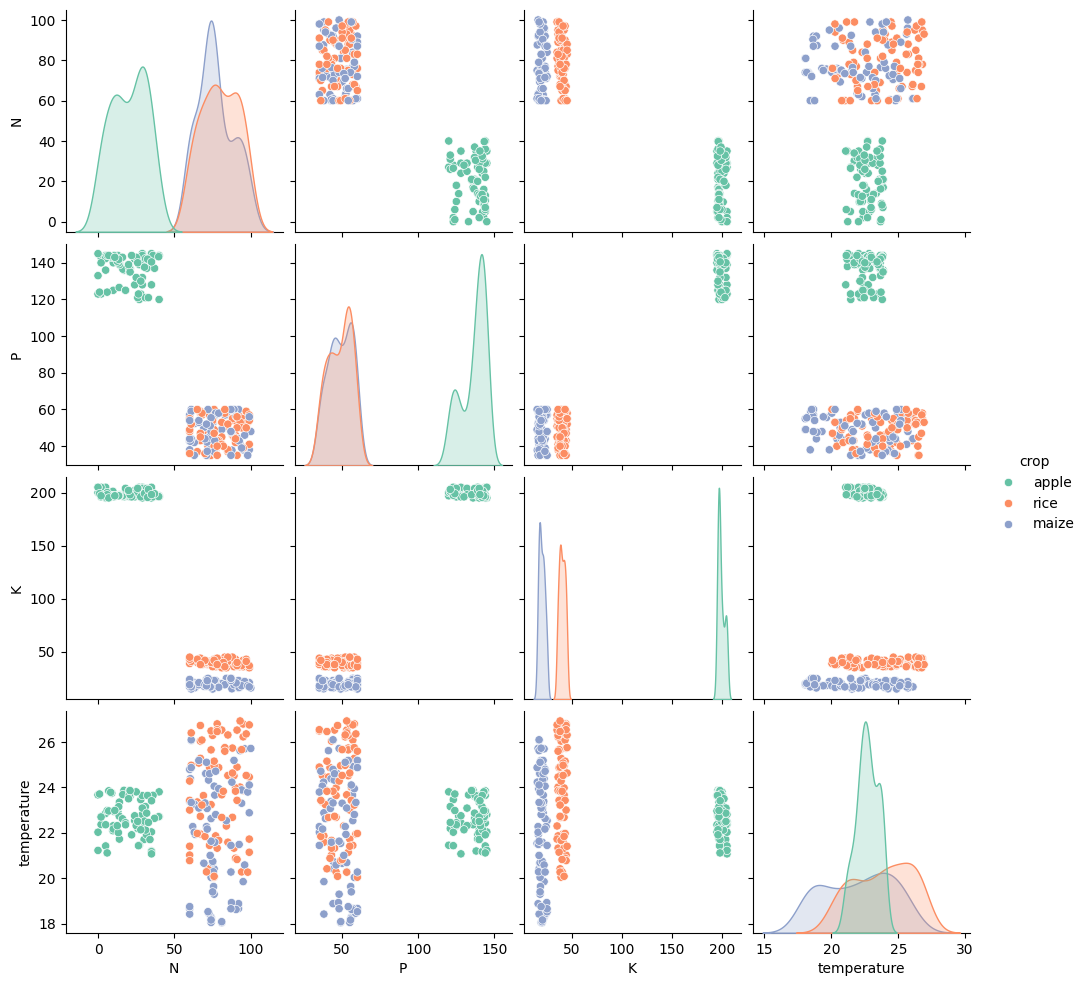

In [172]:
# pairplot - relation b/w npk and temperature

sample_crops = ['rice', 'maize','apple']
df_sample = df[df['crop'].isin(sample_crops)]
# print(df_sample.head())

sns.pairplot(
    df_sample, 
    hue='crop', 
    vars=['N', 'P', 'K', 'temperature'],
    palette='Set2',
    # corner=True,
    )

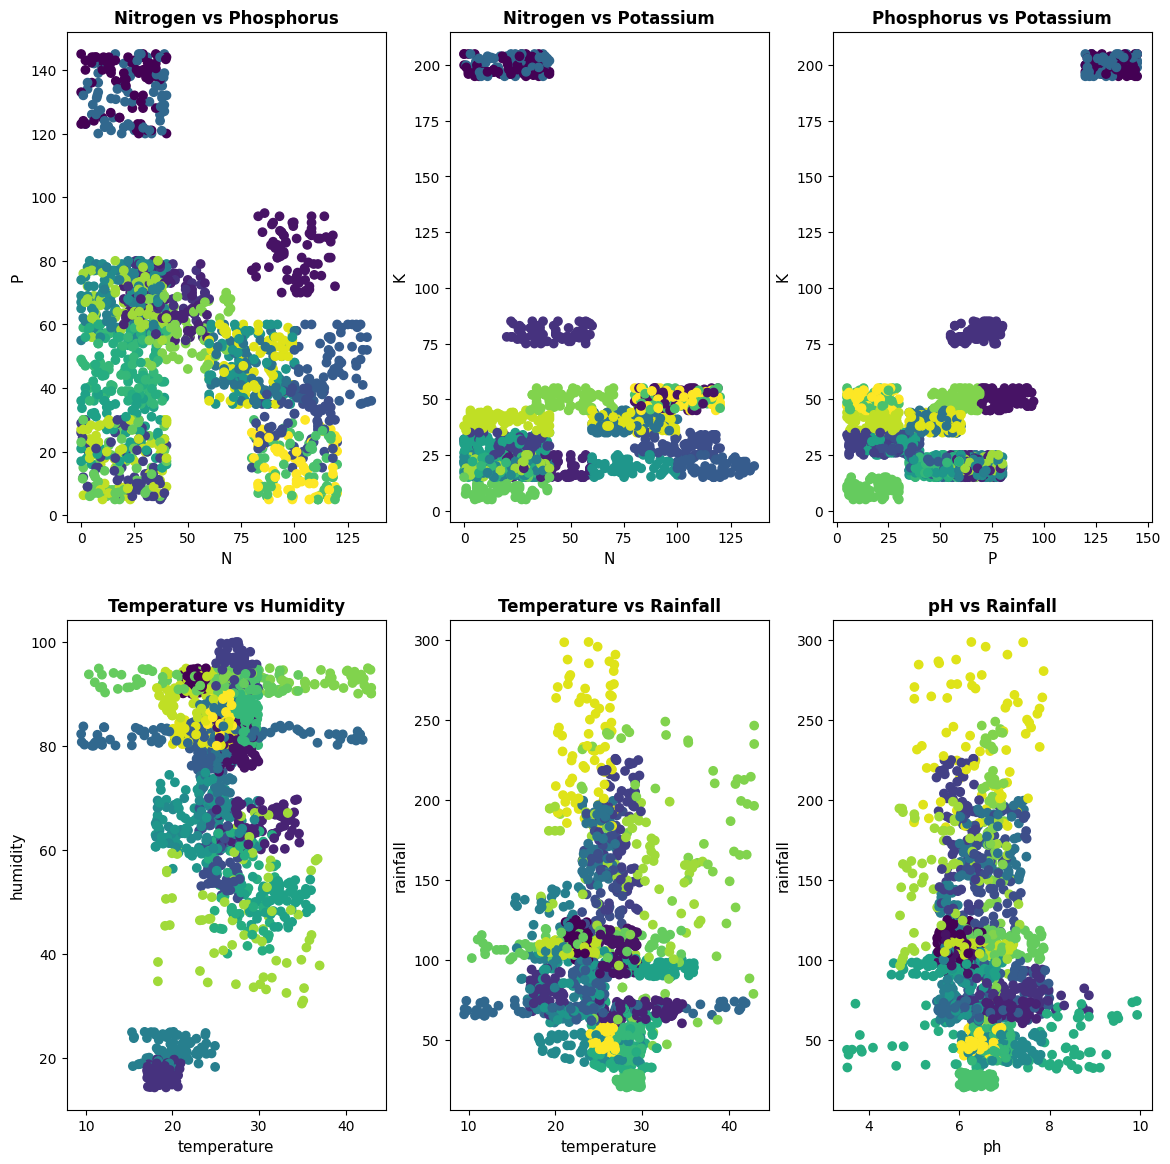

In [244]:
# scatter plot - relation b/w key features

fig, axes = plt.subplots(2, 3, figsize=(14,14))
axes = axes.flatten()

features_pairs = [
    ('N', 'P', 'Nitrogen vs Phosphorus'),
    ('N', 'K', 'Nitrogen vs Potassium'),
    ('P', 'K', 'Phosphorus vs Potassium'),
    ('temperature', 'humidity', 'Temperature vs Humidity'),
    ('temperature', 'rainfall', 'Temperature vs Rainfall'),
    ('ph', 'rainfall', 'pH vs Rainfall')
]

for idx, (x_col, y_col, title) in enumerate(features_pairs):
    ax = axes[idx]
    scatter = ax.scatter(df[x_col], df[y_col], c=df['crop'].astype('category').cat.codes,)

    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel(y_col, fontsize=11)
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')


In [186]:
# correlation matrix - understand linear relationship b/w features

correlation_matrix = df[numerical_cols].corr()
print(correlation_matrix.round(2))

                N     P     K  temperature  humidity    ph  rainfall
N            1.00 -0.23 -0.14         0.01      0.19  0.08      0.05
P           -0.23  1.00  0.74        -0.13     -0.12 -0.15     -0.06
K           -0.14  0.74  1.00        -0.16      0.19 -0.19     -0.05
temperature  0.01 -0.13 -0.16         1.00      0.20 -0.02      0.00
humidity     0.19 -0.12  0.19         0.20      1.00 -0.01      0.11
ph           0.08 -0.15 -0.19        -0.02     -0.01  1.00     -0.14
rainfall     0.05 -0.06 -0.05         0.00      0.11 -0.14      1.00


Text(0.5, 1.0, 'Absolute Correlation Heatmap')

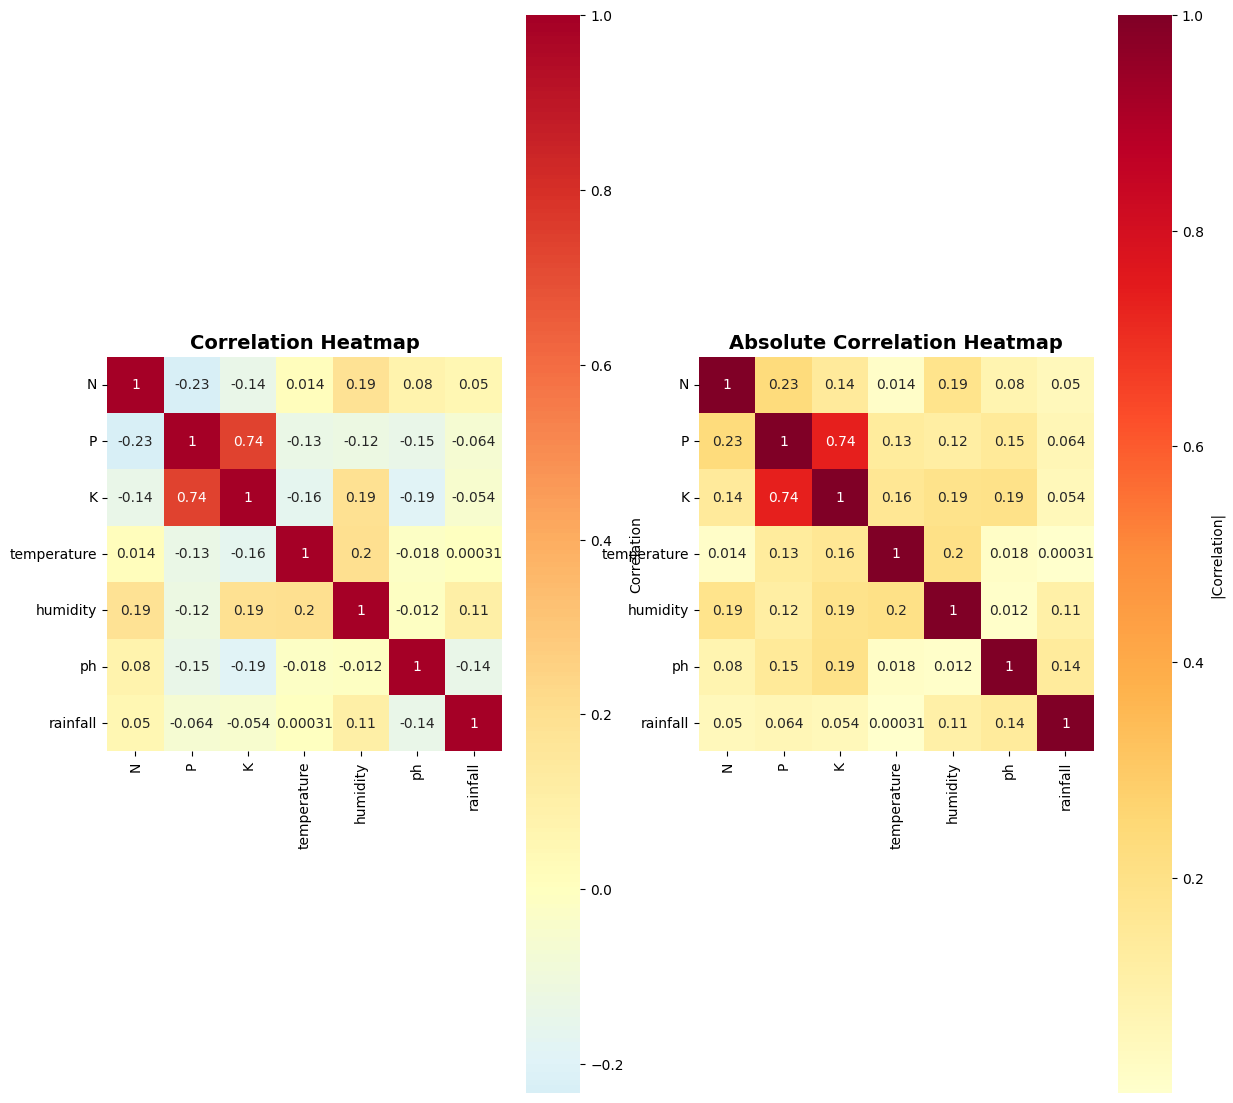

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(14, 14))

# 1. Full Correlation Heatmap
ax1 = axes[0]
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
            square=True, cbar_kws={'label': 'Correlation'}, ax=ax1)
ax1.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# 2. Absolute Correlation Heatmap
ax2 = axes[1]
abs_correlation_matrix = correlation_matrix.abs()
sns.heatmap(abs_correlation_matrix, annot=True, cmap='YlOrRd', 
            square=True, cbar_kws={'label': '|Correlation|'},ax=ax2)
ax2.set_title('Absolute Correlation Heatmap', fontsize=14, fontweight='bold')

In [225]:
# for i in range(len(correlation_matrix)):
#     for j in range(i+1, len(correlation_matrix)):
#         col1 = correlation_matrix.columns[i]
#         col2 = correlation_matrix.columns[j]
#         corr_val = correlation_matrix.iloc[i,j]
#         if abs(corr_val) > 0.5:
#             strength = "strong"
#         elif abs(corr_val) > 0.3:
#             strength = "moderate"
#         else:
#             strength = "weak"
        
#         direction = "positive" if corr_val > 0 else "negative"
#         print(f"{strength} {direction} correlation b/w {col1} and {col2}")
                       

weak negative correlation b/w N and P
weak negative correlation b/w N and K
weak positive correlation b/w N and temperature
weak positive correlation b/w N and humidity
weak positive correlation b/w N and ph
weak positive correlation b/w N and rainfall
strong positive correlation b/w P and K
weak negative correlation b/w P and temperature
weak negative correlation b/w P and humidity
weak negative correlation b/w P and ph
weak negative correlation b/w P and rainfall
weak negative correlation b/w K and temperature
weak positive correlation b/w K and humidity
weak negative correlation b/w K and ph
weak negative correlation b/w K and rainfall
weak positive correlation b/w temperature and humidity
weak negative correlation b/w temperature and ph
weak positive correlation b/w temperature and rainfall
weak negative correlation b/w humidity and ph
weak positive correlation b/w humidity and rainfall
weak negative correlation b/w ph and rainfall


In [232]:
crop_means = df.groupby('crop')[numerical_cols].mean().round(2)
print(crop_means)

                  N       P       K  temperature  humidity    ph  rainfall
crop                                                                      
apple         20.26  136.37  199.07        22.68     92.31  5.90    111.71
banana        99.95   82.25   50.74        27.50     80.21  6.02    104.85
blackgram     39.99   66.89   19.29        29.96     64.96  7.12     68.95
chickpea      41.27   67.67   79.66        18.74     16.78  7.28     80.36
coconut       22.69   15.41   30.75        27.44     95.00  5.98    180.55
coffee       100.62   29.09   29.53        25.72     58.15  6.73    157.95
cotton       116.81   47.16   19.51        23.84     80.28  6.96     79.16
grapes        22.47  131.76  200.17        24.04     81.91  6.03     69.58
jute          78.60   46.30   40.03        25.20     79.75  6.69    172.93
kidneybeans   21.50   67.57   20.38        20.03     21.81  5.76    105.10
lentil        18.48   70.10   19.21        24.49     65.09  6.93     45.20
maize         76.82   48.

Text(58.22222222222221, 0.5, 'Crop Type')

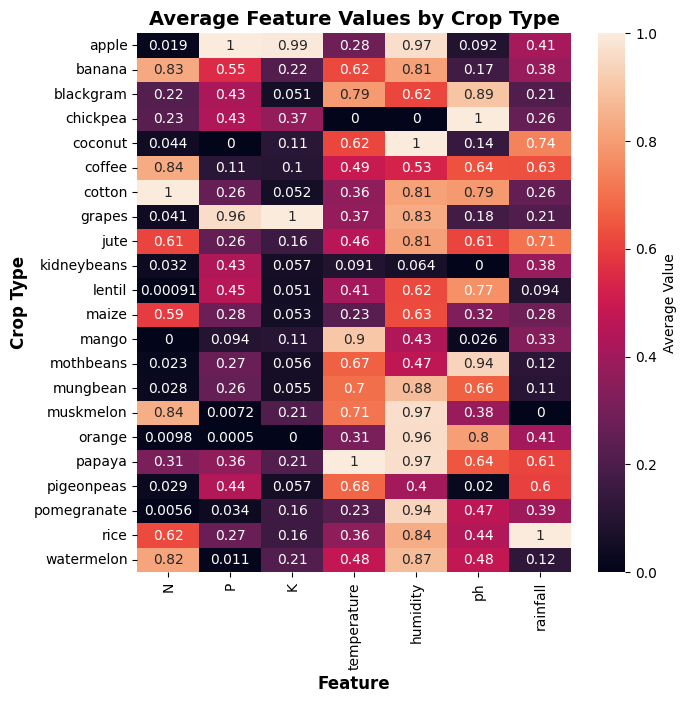

In [242]:
crop_means_normalized = (crop_means - crop_means.min()) / (crop_means.max() - crop_means.min())
# print(crop_means_normalized)

plt.figure(figsize=(7, 7))

sns.heatmap(crop_means_normalized, annot=True,  cbar_kws={'label': 'Average Value'})
plt.title('Average Feature Values by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Feature', fontsize=12, fontweight='bold')
plt.ylabel('Crop Type', fontsize=12, fontweight='bold')